<a href="https://colab.research.google.com/github/CodeWithradhika/CSET343./blob/main/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2

import warnings
warnings.filterwarnings("ignore")

In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print("First 5 rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
medical_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("Number of zero values:")

for col in medical_columns:
    print(col, ":", (df[col] == 0).sum())

Number of zero values:
Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


In [ ]:
df_clean = df.copy()

for col in medical_columns:
    df_clean[col] = df_clean[col].replace(0, np.nan)

print("Missing values after replacing invalid zeros:")
print(df_clean.isnull().sum())

Missing values after replacing invalid zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [ ]:
for col in medical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Missing values after imputation:")
print(df_clean.isnull().sum())

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


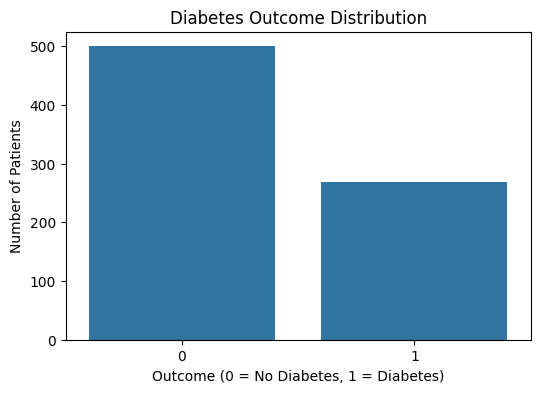

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="Outcome", data=df_clean)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")

plt.show()

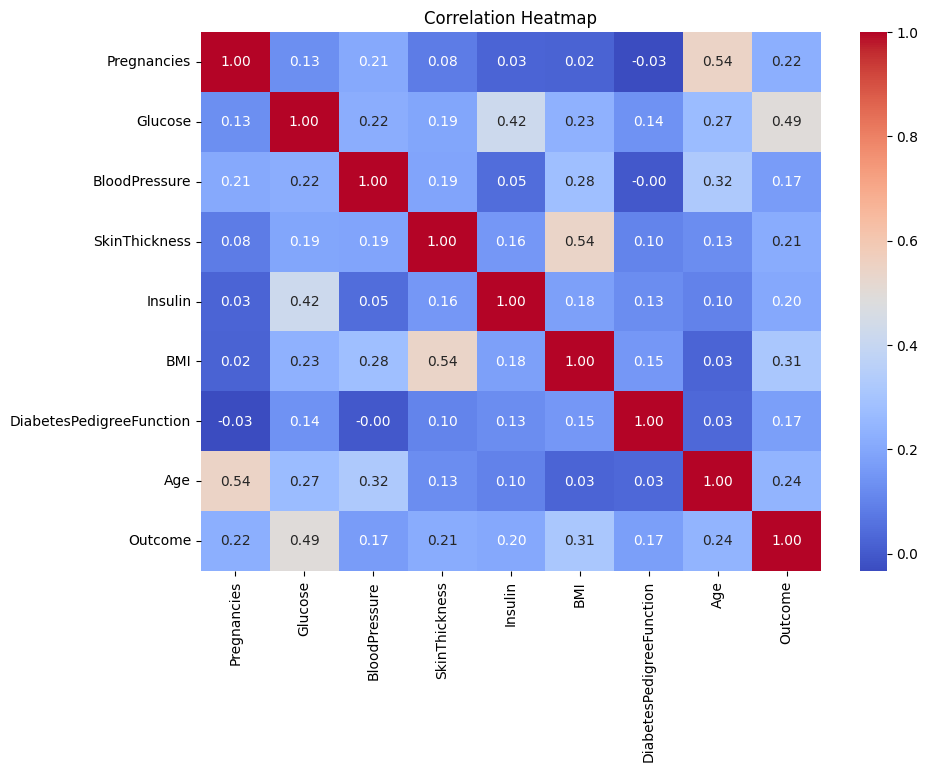

In [ ]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df_clean.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
df_clean["BMI_Category"] = pd.cut(
    df_clean["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

df_clean["Age_Group"] = pd.cut(
    df_clean["Age"],
    bins=[0, 30, 50, 100],
    labels=["Young", "Middle", "Senior"]
)

display(df_clean.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,Obese,Middle
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,Overweight,Middle
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,Normal,Middle
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Overweight,Young
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Obese,Middle


In [ ]:
diabetic = df_clean[df_clean["Outcome"] == 1]["Glucose"]
non_diabetic = df_clean[df_clean["Outcome"] == 0]["Glucose"]

t_stat, p_value = stats.ttest_ind(
    diabetic,
    non_diabetic,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: There is a significant difference in glucose levels.")
else:
    print("Fail to reject H0: No significant difference found.")

T-statistic: 14.852653441079662
P-value: 3.5421485614431447e-41
Reject H0: There is a significant difference in glucose levels.


In [ ]:
contingency_table = pd.crosstab(
    df_clean["BMI_Category"],
    df_clean["Outcome"]
)

print("Contingency Table:")
display(contingency_table)

chi2_stat, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square Statistic:", chi2_stat)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)

if p_value < 0.05:
    print("Reject H0: BMI category and diabetes outcome are associated.")
else:
    print("Fail to reject H0: No significant association found.")

Contingency Table:


Outcome,0,1
BMI_Category,,
Underweight,4,0
Normal,101,7
Overweight,136,44
Obese,259,217


Chi-Square Statistic: 73.13331881767633
P-value: 9.101656268510895e-16
Degrees of Freedom: 3
Reject H0: BMI category and diabetes outcome are associated.


In [ ]:
groups = []

for category in df_clean["BMI_Category"].dropna().unique():
    group = df_clean[
        df_clean["BMI_Category"] == category
    ]["Glucose"]

    groups.append(group)

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: At least one BMI group has a different mean glucose level.")
else:
    print("Fail to reject H0.")

F-statistic: 13.254241118590004
P-value: 1.9249439734881206e-08
Reject H0: At least one BMI group has a different mean glucose level.


In [ ]:
X = df_clean[
    [
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age"
    ]
]

y = df_clean["Outcome"]

selector = SelectKBest(
    score_func=chi2,
    k=5
)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(list(selected_features))

Selected Features:
['Pregnancies', 'Glucose', 'Insulin', 'BMI', 'Age']


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("Scaled data:")
display(X_scaled.head())

Scaled data:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.866045,-0.031990,0.670643,-0.181541,0.166619,0.468492,1.425995
1,-0.844885,-1.205066,-0.528319,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672
2,1.233880,2.016662,-0.693761,-0.012301,-0.181541,-1.332500,0.604397,-0.105584
3,-0.844885,-1.073567,-0.528319,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549
4,-1.141852,0.504422,-2.679076,0.670643,0.316566,1.549303,5.484909,-0.020496


In [ ]:
!pip install nltk -q

In [ ]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving mtsamples.csv to mtsamples.csv


In [ ]:
filename = list(uploaded.keys())[0]

text_df = pd.read_csv(filename)

print("Shape:", text_df.shape)

display(text_df.head())

Shape: (4999, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [ ]:
print("Columns:")
print(text_df.columns.tolist())

print("\nMissing values:")
print(text_df.isnull().sum())

Columns:
['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

Missing values:
Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64


In [ ]:
text_df = text_df.dropna()

print("Shape after removing missing values:")
print(text_df.shape)

Shape after removing missing values:
(3898, 6)


In [ ]:
import re

def clean_text(text):
    # Convert value to string
    text = str(text)

    # Convert text to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    # Remove spaces from beginning and end
    return text.strip()


# Apply cleaning to the transcription column
text_df["cleaned_text"] = text_df["transcription"].apply(clean_text)

# Display original and cleaned text
display(
    text_df[["transcription", "cleaned_text"]].head()
)

,transcription,cleaned_text
0,"SUBJECTIVE:, This 23-year-old white female pr...",subjective this yearold white female presents ...
1,"PAST MEDICAL HISTORY:, He has difficulty climb...",past medical history he has difficulty climbin...
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...",history of present illness i have seen abc tod...
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...",d mmode left atrial enlargement with left atri...
4,1. The left ventricular cavity size and wall ...,the left ventricular cavity size and wall thic...


In [ ]:
def remove_phi(text):

    # Remove phone numbers
    text = re.sub(r"\b\d{10}\b", "[PHONE]", text)

    # Remove email addresses
    text = re.sub(
        r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
        "[EMAIL]",
        text
    )

    # Remove dates
    text = re.sub(
        r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b",
        "[DATE]",
        text
    )

    return text


text_df["phi_removed_text"] = text_df["cleaned_text"].apply(remove_phi)

display(text_df[["cleaned_text", "phi_removed_text"]].head())

,cleaned_text,phi_removed_text
0,subjective this yearold white female presents ...,subjective this yearold white female presents ...
1,past medical history he has difficulty climbin...,past medical history he has difficulty climbin...
2,history of present illness i have seen abc tod...,history of present illness i have seen abc tod...
3,d mmode left atrial enlargement with left atri...,d mmode left atrial enlargement with left atri...
4,the left ventricular cavity size and wall thic...,the left ventricular cavity size and wall thic...


In [ ]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.tokenize import word_tokenize

text_df["tokens"] = text_df["phi_removed_text"].apply(word_tokenize)

display(
    text_df[["phi_removed_text", "tokens"]].head()
)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,phi_removed_text,tokens
0,subjective this yearold white female presents ...,"[subjective, this, yearold, white, female, pre..."
1,past medical history he has difficulty climbin...,"[past, medical, history, he, has, difficulty, ..."
2,history of present illness i have seen abc tod...,"[history, of, present, illness, i, have, seen,..."
3,d mmode left atrial enlargement with left atri...,"[d, mmode, left, atrial, enlargement, with, le..."
4,the left ventricular cavity size and wall thic...,"[the, left, ventricular, cavity, size, and, wa..."


In [ ]:
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def remove_stopwords(tokens):
    return [
        word for word in tokens
        if word not in stop_words
    ]

text_df["processed_tokens"] = text_df["tokens"].apply(
    remove_stopwords
)

display(
    text_df[["tokens", "processed_tokens"]].head()
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,tokens,processed_tokens
0,"[subjective, this, yearold, white, female, pre...","[subjective, yearold, white, female, presents,..."
1,"[past, medical, history, he, has, difficulty, ...","[past, medical, history, difficulty, climbing,..."
2,"[history, of, present, illness, i, have, seen,...","[history, present, illness, seen, abc, today, ..."
3,"[d, mmode, left, atrial, enlargement, with, le...","[mmode, left, atrial, enlargement, left, atria..."
4,"[the, left, ventricular, cavity, size, and, wa...","[left, ventricular, cavity, size, wall, thickn..."


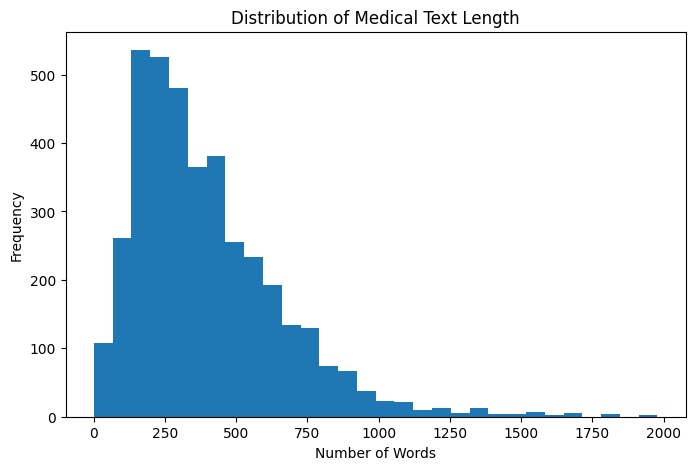

In [ ]:
text_df["text_length"] = text_df["phi_removed_text"].apply(
    lambda x: len(x.split())
)

plt.figure(figsize=(8,5))

plt.hist(text_df["text_length"], bins=30)

plt.title("Distribution of Medical Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

In [ ]:
uploaded = files.upload()